Loading Functions

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency, kruskal
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
 

# GLOBAL STYLE ────────────────────────────────────────────────────────────

In [4]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150,
})

PALETTE   = ['#1B4F72', '#2E86C1', '#A9CCE3', '#D6EAF8', '#F39C12', '#E74C3C']
BLUE_MAIN = '#1B4F72'
RED_MAIN  = '#E74C3C'
ORANGE    = '#F39C12'

OUTPUT = 'outputs/'

# LOAD & CLEAN ─────────────────────────────────────────────────────────────

In [5]:
df_raw = pd.read_csv('FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv')

# Keep only rows with a valid ERR

df = df_raw.dropna(subset=['Excess Readmission Ratio']).copy()
df['Number of Discharges'] = pd.to_numeric(df['Number of Discharges'], errors='coerce')

# Shorten measure names

measure_map = {
    'READM-30-AMI-HRRP':      'Heart Attack (AMI)',
    'READM-30-HF-HRRP':       'Heart Failure (HF)',
    'READM-30-PN-HRRP':       'Pneumonia (PN)',
    'READM-30-COPD-HRRP':     'COPD',
    'READM-30-HIP-KNEE-HRRP': 'Hip/Knee (THA/TKA)',
    'READM-30-CABG-HRRP':     'Heart Surgery (CABG)',
}
df['Condition'] = df['Measure Name'].map(measure_map)

# Flag hospitals with ERR > 1 (excess readmissions = potential penalty)

df['Excess_Flag'] = df['Excess Readmission Ratio'] > 1.0
 
print(f"Dataset: {df.shape[0]:,} hospital-condition records")
print(f"Unique hospitals: {df['Facility ID'].nunique():,}")
print(f"States: {df['State'].nunique()}")
print(f"Records with ERR > 1 (excess): {df['Excess_Flag'].sum():,} ({df['Excess_Flag'].mean()*100:.1f}%)")
print(f"\nERR stats:\n{df['Excess Readmission Ratio'].describe().round(4)}")
 

Dataset: 11,720 hospital-condition records
Unique hospitals: 2,833
States: 51
Records with ERR > 1 (excess): 5,643 (48.1%)

ERR stats:
count    11720.0000
mean         1.0018
std          0.0821
min          0.4698
25%          0.9582
50%          0.9973
75%          1.0423
max          1.6297
Name: Excess Readmission Ratio, dtype: float64


# FIGURE 1: ERR Distribution by Condition ─────────────────────────────────

✓ Figure 1 saved


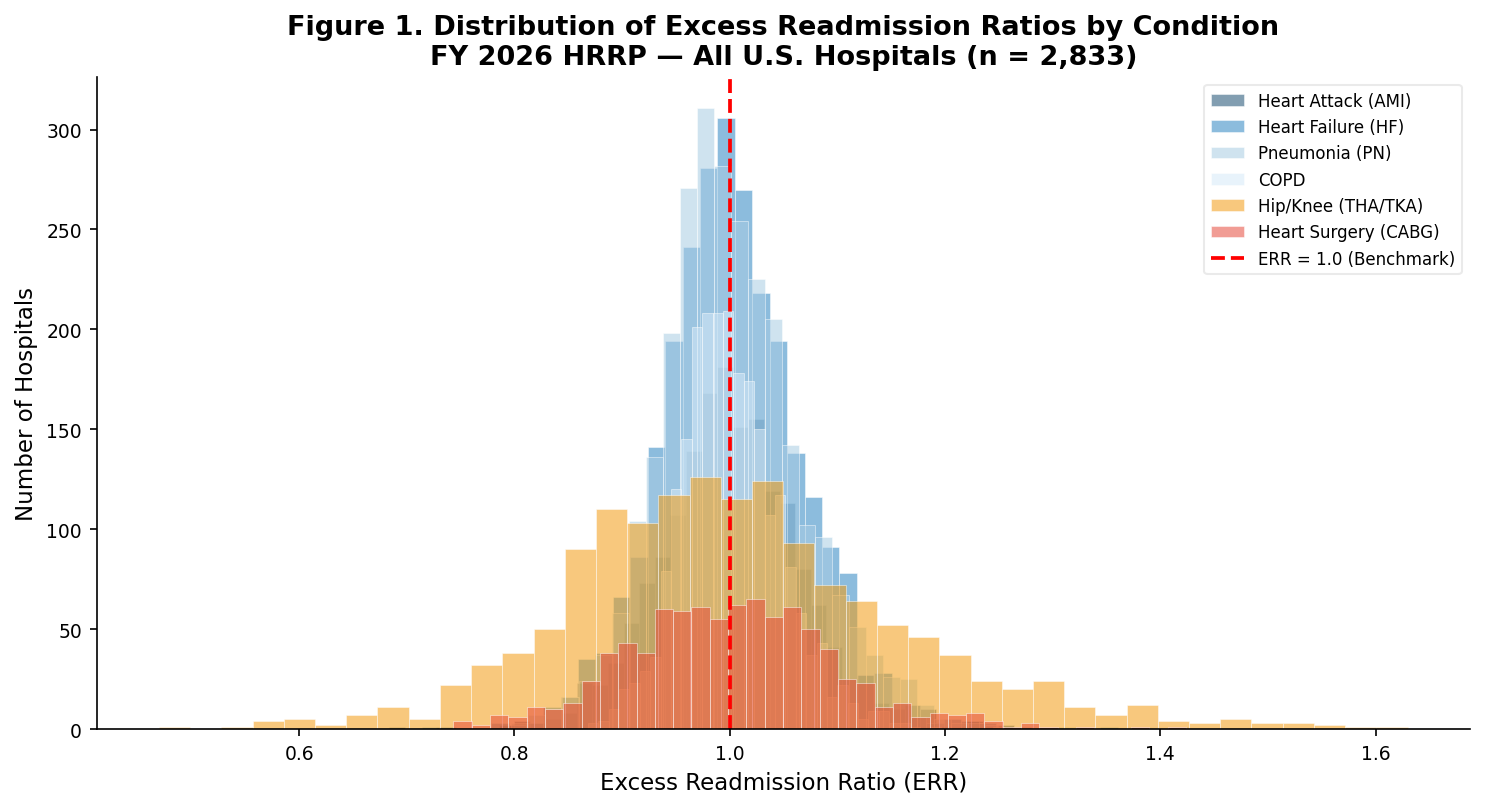

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
conditions = list(measure_map.values())
colors = PALETTE

for i, cond in enumerate(conditions):
    sub = df[df['Condition'] == cond]['Excess Readmission Ratio']
    ax.hist(sub, bins=40, alpha=0.55, label=cond, color=colors[i], edgecolor='white', linewidth=0.4)

ax.axvline(1.0, color='red', linestyle='--', linewidth=1.8, label='ERR = 1.0 (Benchmark)')
ax.set_xlabel('Excess Readmission Ratio (ERR)')
ax.set_ylabel('Number of Hospitals')
ax.set_title('Figure 1. Distribution of Excess Readmission Ratios by Condition\n'
             'FY 2026 HRRP — All U.S. Hospitals (n = {:,})'.format(df['Facility ID'].nunique()))
ax.legend(fontsize=8, framealpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig1_err_distribution.png', bbox_inches='tight')
print("✓ Figure 1 saved")
plt.show()

# FIGURE 2: % Hospitals with ERR > 1 by Condition (Bar) ───────────────────────────────────────────────────────────────

✓ Figure 2 saved


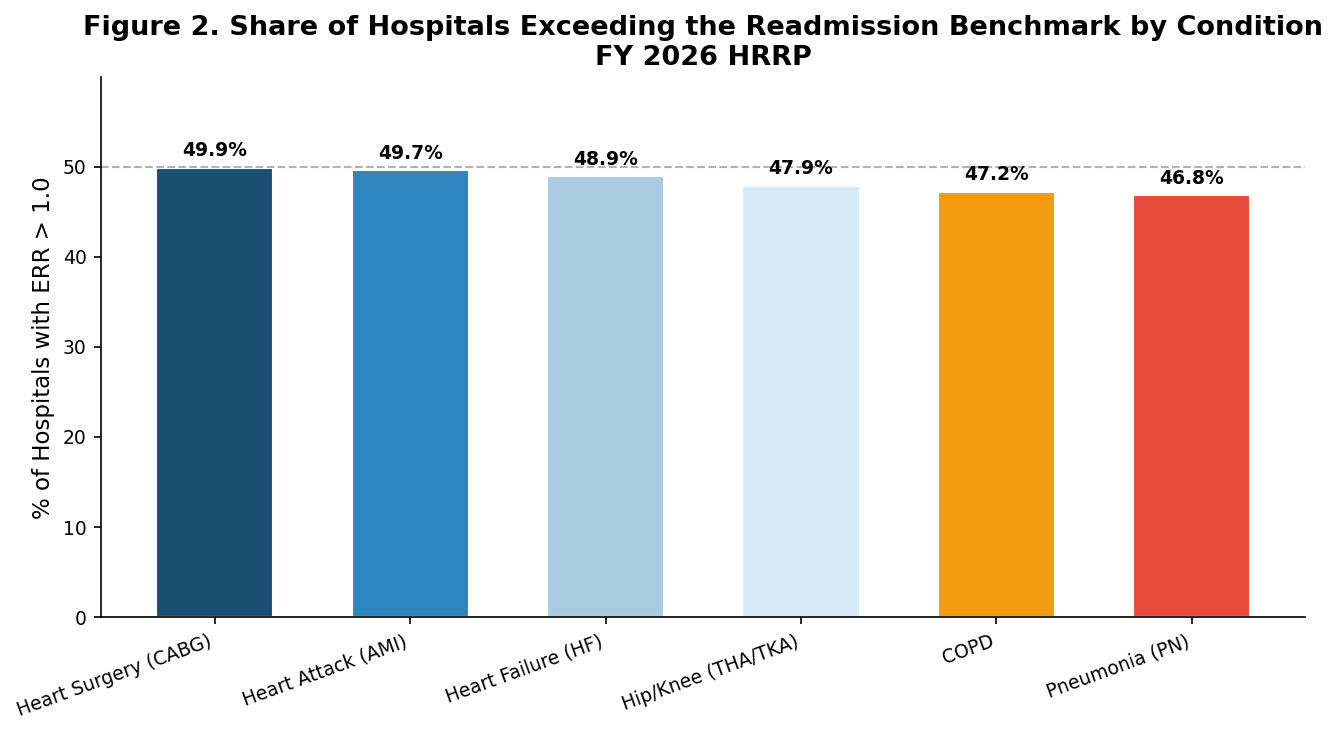

In [7]:
excess_rate = df.groupby('Condition')['Excess_Flag'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(excess_rate.index, excess_rate.values,
              color=[PALETTE[i] for i in range(len(excess_rate))],
              edgecolor='white', width=0.6)
ax.axhline(50, color='grey', linestyle='--', linewidth=1, alpha=0.6, label='50% reference')
for bar, val in zip(bars, excess_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.8, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('% of Hospitals with ERR > 1.0')
ax.set_title('Figure 2. Share of Hospitals Exceeding the Readmission Benchmark by Condition\n'
             'FY 2026 HRRP')
ax.set_xticklabels(excess_rate.index, rotation=20, ha='right')
ax.set_ylim(0, excess_rate.max() + 10)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig2_excess_by_condition.png', bbox_inches='tight')
print("✓ Figure 2 saved")
plt.show()

# FIGURE 3: Mean ERR by State (Top & Bottom 10) ──────────────────────────────────────────────────────

✓ Figure 3 saved


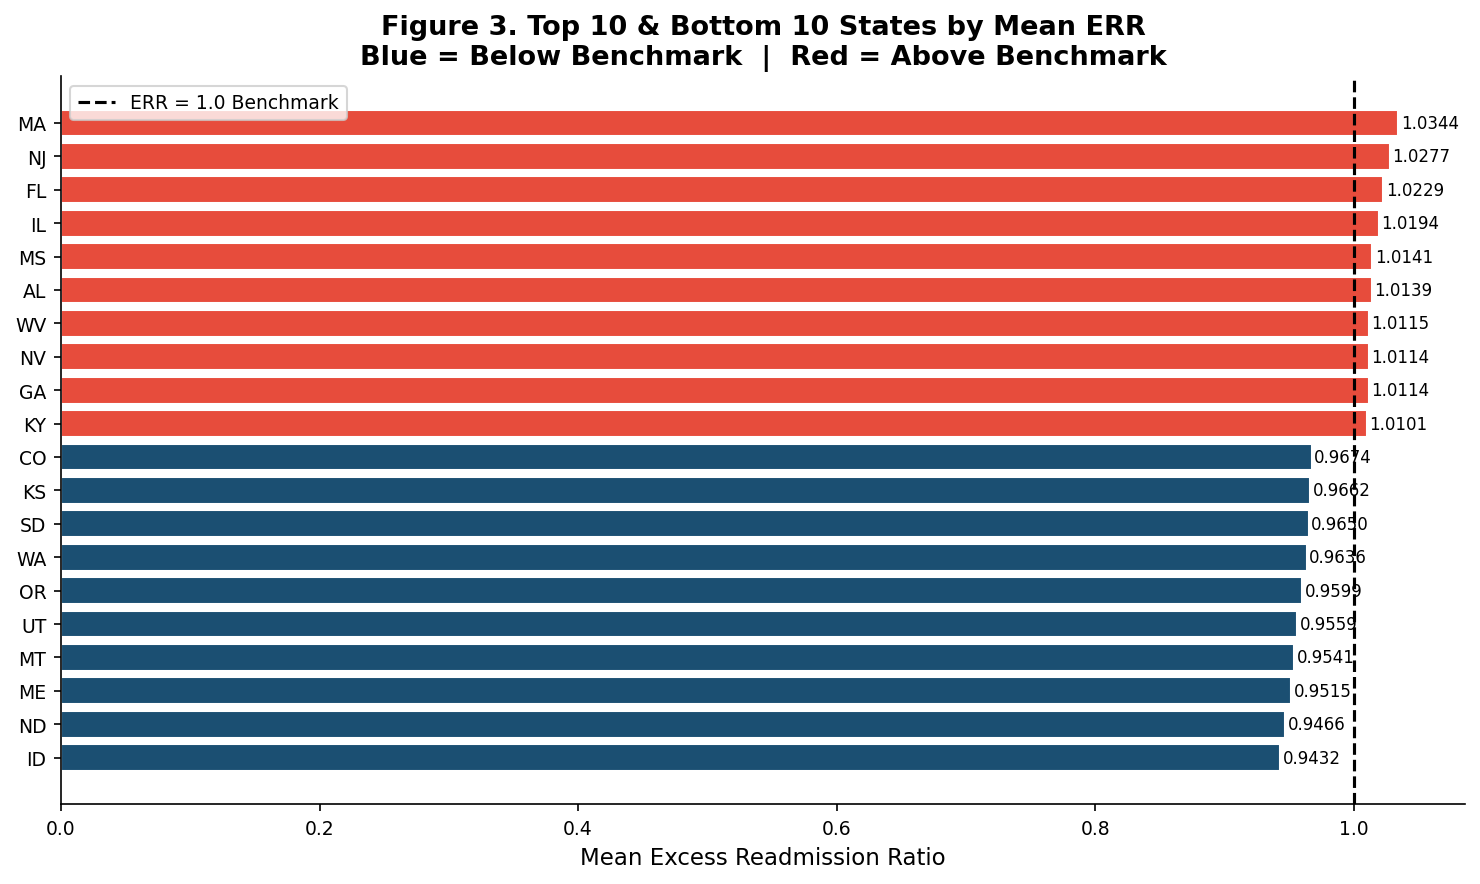

In [8]:
state_err = df.groupby('State')['Excess Readmission Ratio'].mean().sort_values()
top10    = state_err.tail(10)
bottom10 = state_err.head(10)
combined = pd.concat([bottom10, top10])
 
colors_bar = [BLUE_MAIN if v < 1.0 else RED_MAIN for v in combined.values]
 
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(combined.index, combined.values, color=colors_bar, edgecolor='white')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='ERR = 1.0 Benchmark')
ax.set_xlabel('Mean Excess Readmission Ratio')
ax.set_title('Figure 3. Top 10 & Bottom 10 States by Mean ERR\n'
             'Blue = Below Benchmark  |  Red = Above Benchmark')
ax.legend(fontsize=9)
for bar, val in zip(bars, combined.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig3_state_err_top_bottom.png', bbox_inches='tight')
print("✓ Figure 3 saved")
plt.show()

# FIGURE 4: Heatmap — Mean ERR by State × Condition ──────────────────────────────────────────────────

✓ Figure 4 saved


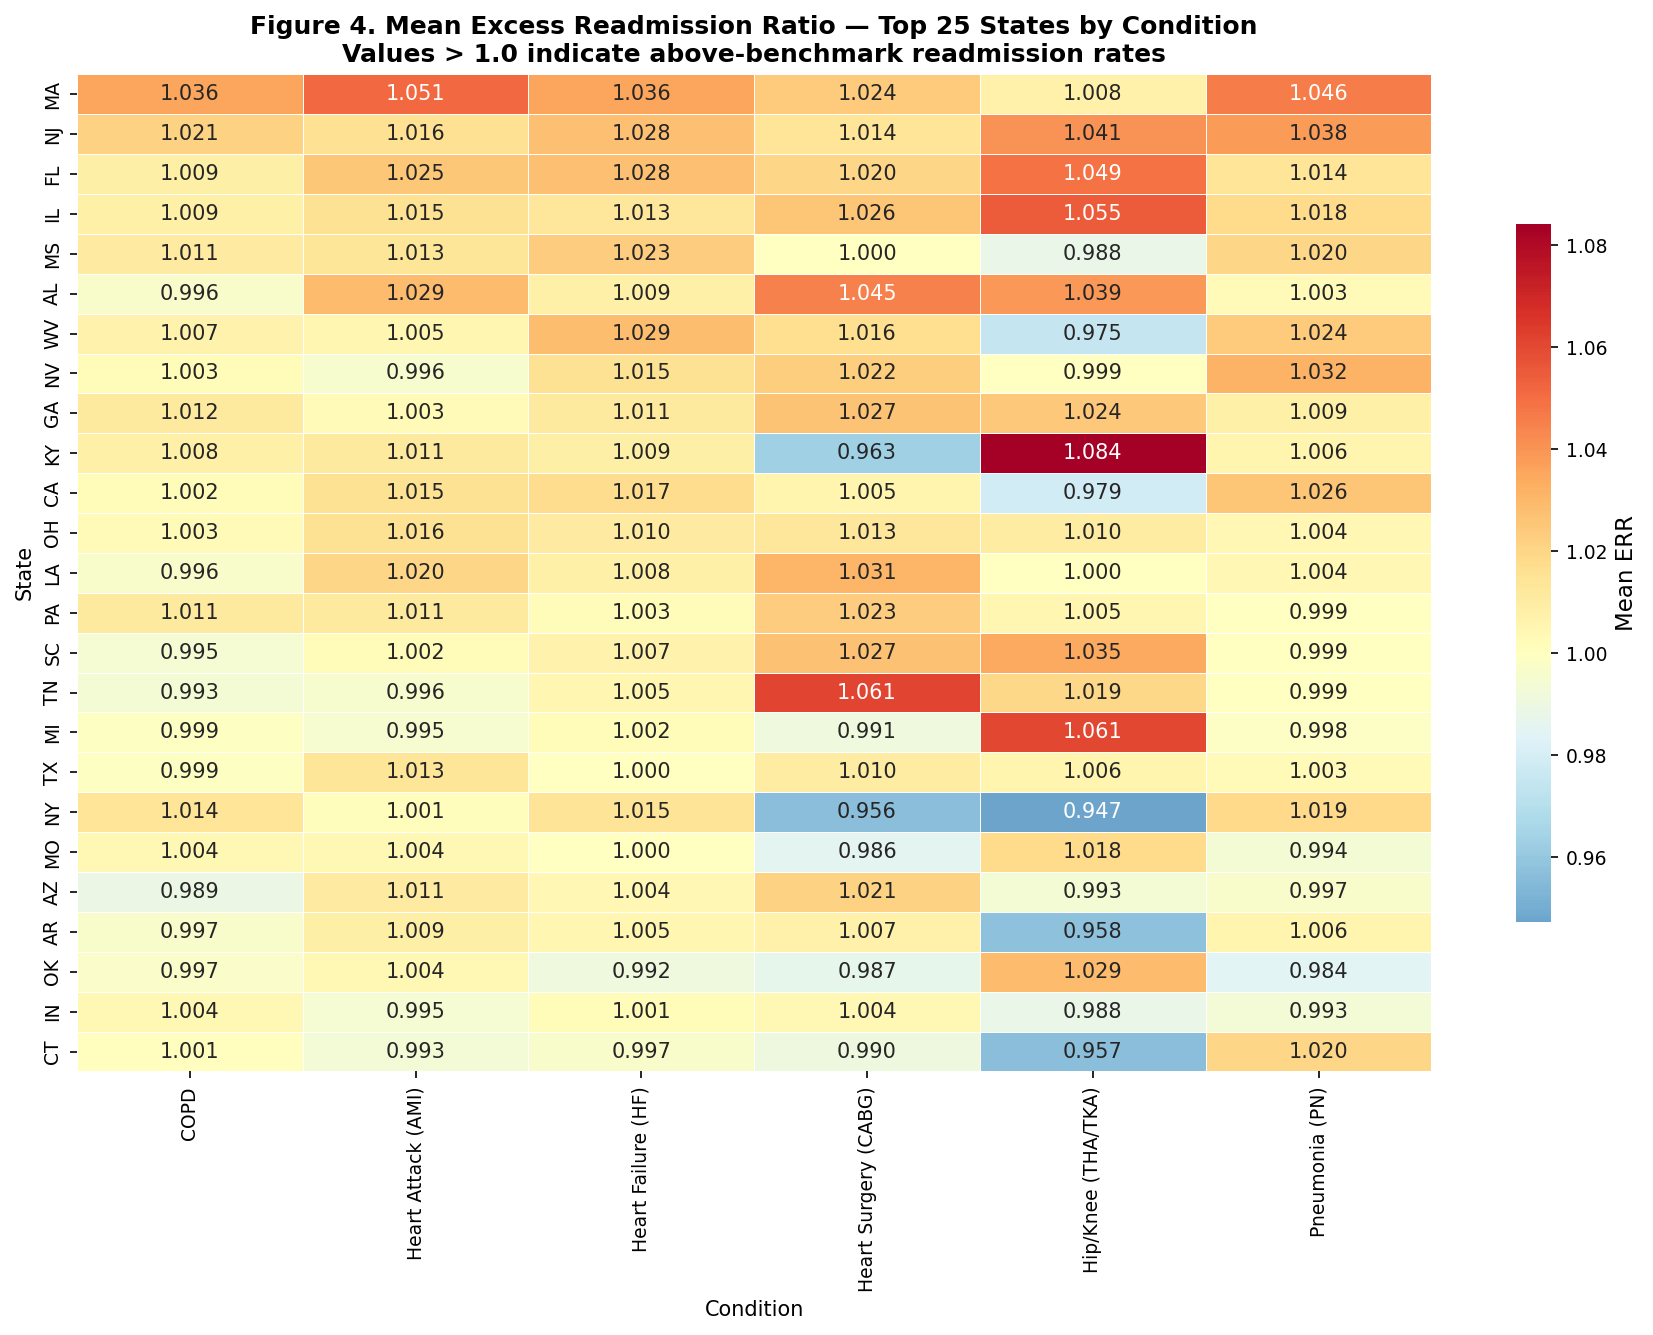

In [9]:
pivot = df.pivot_table(values='Excess Readmission Ratio',
                       index='State', columns='Condition', aggfunc='mean')

# Pick top 25 states by overall mean ERR for readability

top_states = df.groupby('State')['Excess Readmission Ratio'].mean().nlargest(25).index
pivot_top = pivot.loc[top_states]
 
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(pivot_top, cmap='RdYlBu_r', center=1.0, annot=True, fmt='.3f',
            linewidths=0.4, linecolor='white', ax=ax,
            cbar_kws={'label': 'Mean ERR', 'shrink': 0.7})
ax.set_title('Figure 4. Mean Excess Readmission Ratio — Top 25 States by Condition\n'
             'Values > 1.0 indicate above-benchmark readmission rates', fontsize=12)
ax.set_xlabel('Condition', fontsize=10)
ax.set_ylabel('State', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig4_heatmap_state_condition.png', bbox_inches='tight')
print("✓ Figure 4 saved")
plt.show()

# FIGURE 5: Boxplot — ERR by Condition ───────────────────────────────────────────────────────────────

✓ Figure 5 saved


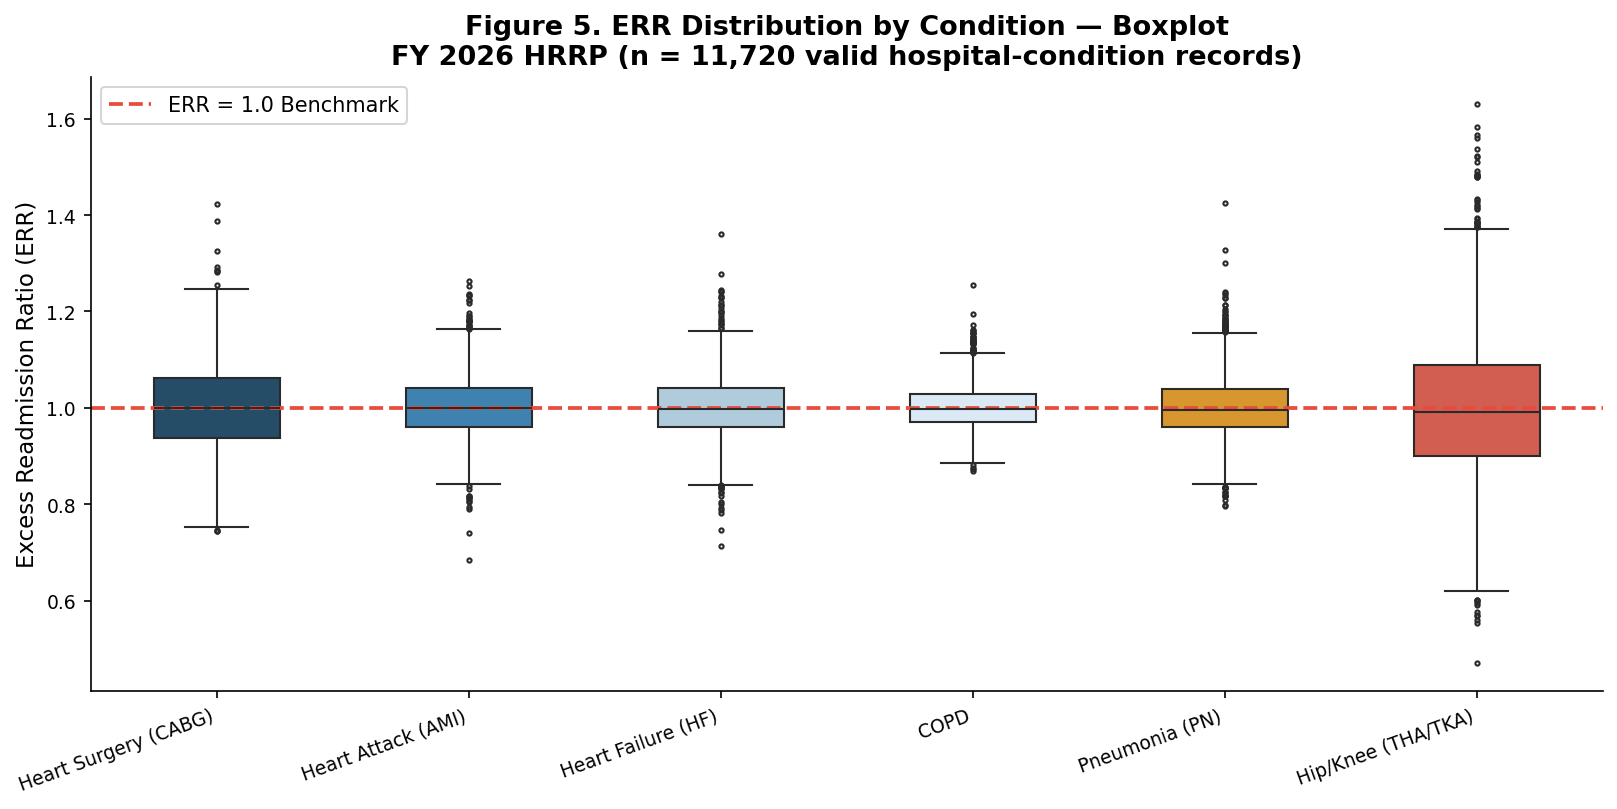

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
order = df.groupby('Condition')['Excess Readmission Ratio'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Condition', y='Excess Readmission Ratio',
            order=order, palette=PALETTE, width=0.5, fliersize=2, ax=ax)
ax.axhline(1.0, color=RED_MAIN, linestyle='--', linewidth=1.8, label='ERR = 1.0 Benchmark')
ax.set_xlabel('')
ax.set_ylabel('Excess Readmission Ratio (ERR)')
ax.set_title('Figure 5. ERR Distribution by Condition — Boxplot\n'
             'FY 2026 HRRP (n = {:,} valid hospital-condition records)'.format(len(df)))
ax.set_xticklabels(order, rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT + 'fig5_boxplot_condition.png', bbox_inches='tight')
print("✓ Figure 5 saved")
plt.show()

# FIGURE 6: Predicted vs Expected Readmission Rate (Scatter) ──────────────────────────────────────────────────────

✓ Figure 6 saved


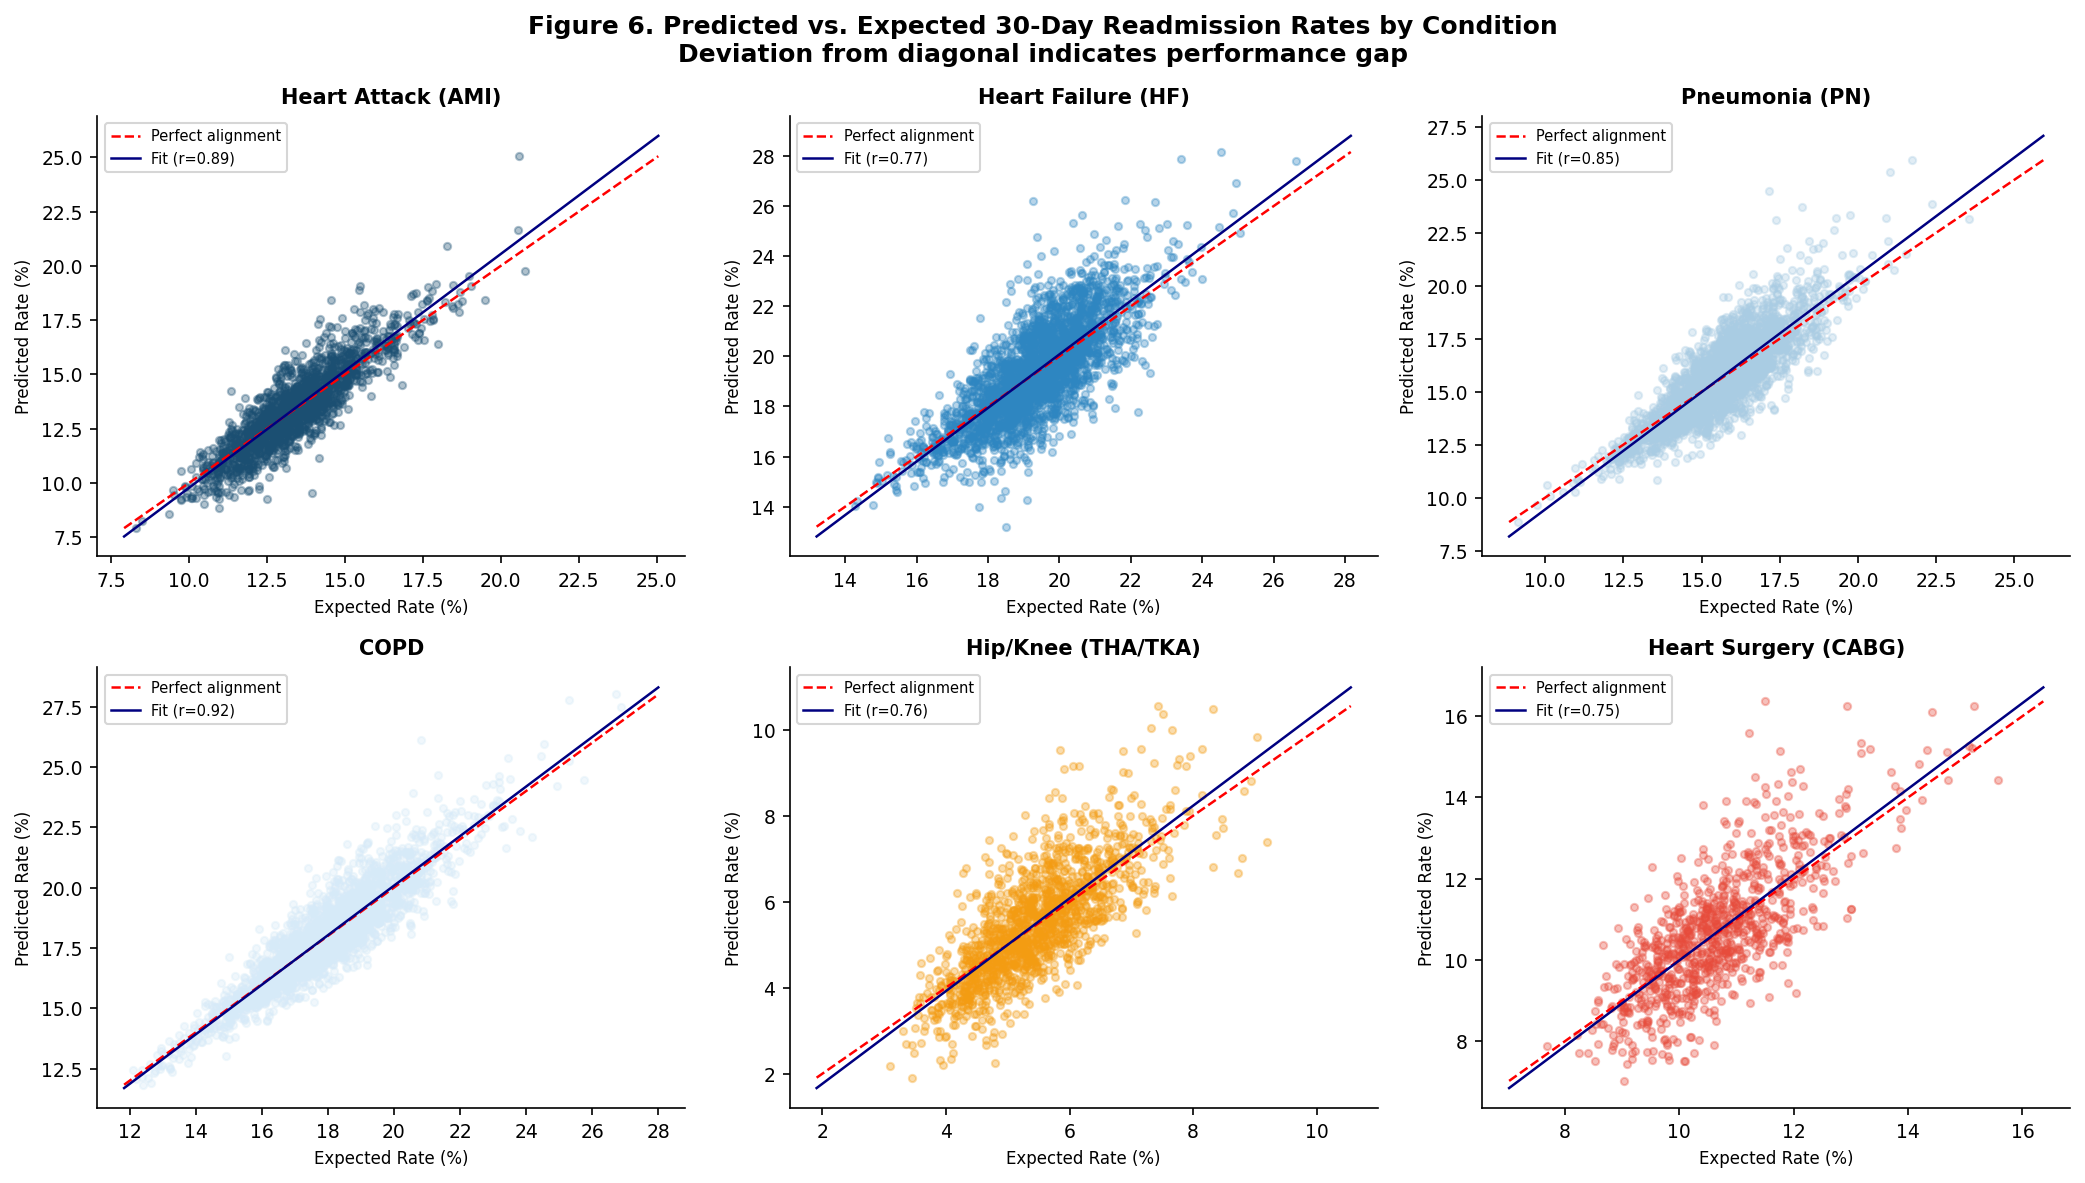

In [11]:
df_scatter = df.dropna(subset=['Predicted Readmission Rate', 'Expected Readmission Rate'])
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes = axes.flatten()
for i, cond in enumerate(conditions):
    sub = df_scatter[df_scatter['Condition'] == cond]
    axes[i].scatter(sub['Expected Readmission Rate'], sub['Predicted Readmission Rate'],
                    alpha=0.35, s=12, color=PALETTE[i])
    # Perfect line
    mn = min(sub['Expected Readmission Rate'].min(), sub['Predicted Readmission Rate'].min())
    mx = max(sub['Expected Readmission Rate'].max(), sub['Predicted Readmission Rate'].max())
    axes[i].plot([mn, mx], [mn, mx], 'r--', linewidth=1.2, label='Perfect alignment')
    # Regression line
    slope, intercept, r, p, _ = stats.linregress(sub['Expected Readmission Rate'],
                                                   sub['Predicted Readmission Rate'])
    x_line = np.linspace(mn, mx, 100)
    axes[i].plot(x_line, intercept + slope * x_line, color='navy', linewidth=1.2,
                 label=f'Fit (r={r:.2f})')
    axes[i].set_title(cond, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Expected Rate (%)', fontsize=8)
    axes[i].set_ylabel('Predicted Rate (%)', fontsize=8)
    axes[i].legend(fontsize=7)
 
fig.suptitle('Figure 6. Predicted vs. Expected 30-Day Readmission Rates by Condition\n'
             'Deviation from diagonal indicates performance gap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT + 'fig6_predicted_vs_expected.png', bbox_inches='tight')
print("✓ Figure 6 saved")
plt.show()

# FIGURE 7: Correlation Heatmap ──────────────────────────────────────────────────────────────────────

✓ Figure 7 saved


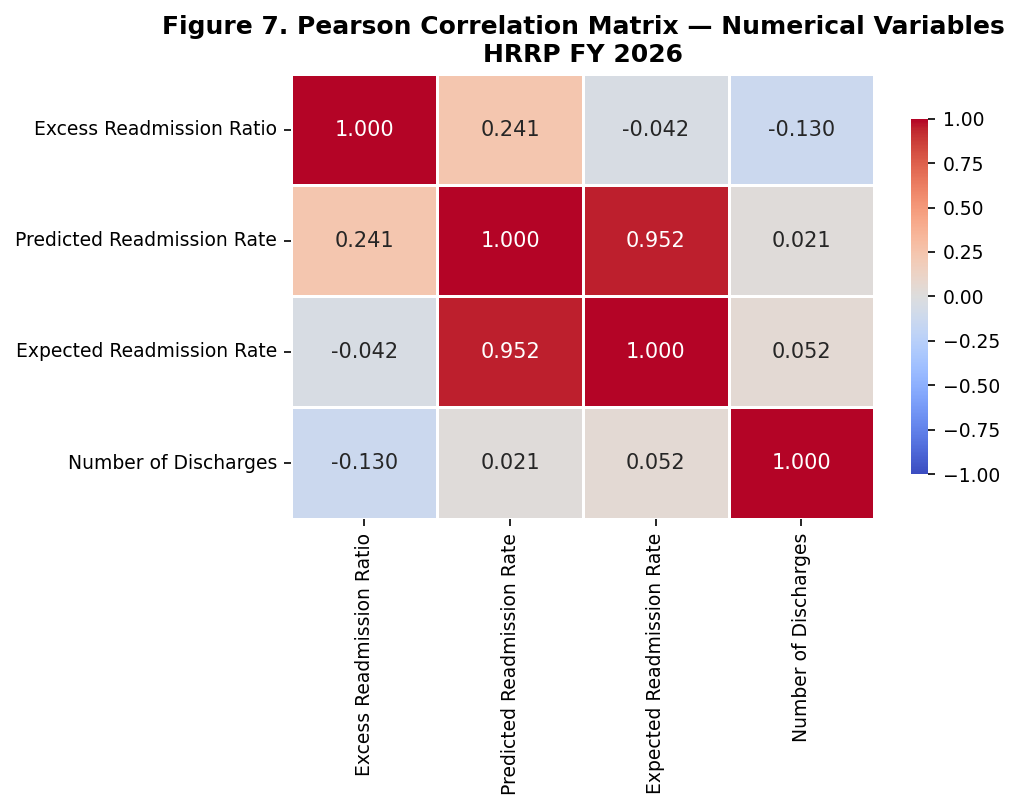

In [12]:
num_cols = ['Excess Readmission Ratio', 'Predicted Readmission Rate',
            'Expected Readmission Rate', 'Number of Discharges']
corr_df = df[num_cols].dropna()
corr_matrix = corr_df.corr()
 
fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Figure 7. Pearson Correlation Matrix — Numerical Variables\n'
             'HRRP FY 2026', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig7_correlation_heatmap.png', bbox_inches='tight')
print("✓ Figure 7 saved")
plt.show()

# FIGURE 8: ANOVA — ERR across Conditions ────────────────────────────────────────────────────────────

✓ Table 1 saved


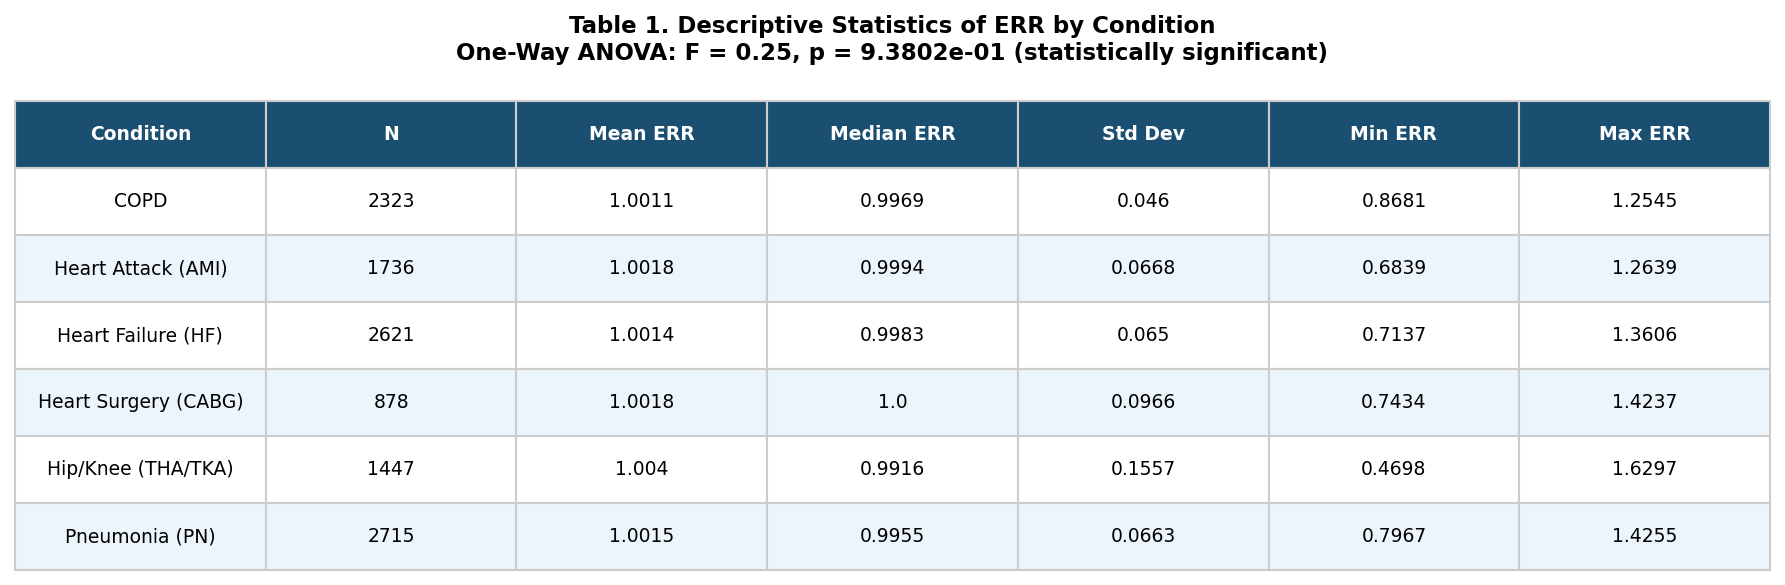

In [13]:
groups = [df[df['Condition'] == c]['Excess Readmission Ratio'].dropna().values
          for c in conditions]
f_stat, p_val = f_oneway(*groups)
 
# Summary stats table for conditions
summary = df.groupby('Condition')['Excess Readmission Ratio'].agg(
    N='count', Mean='mean', Median='median', Std='std',
    Min='min', Max='max'
).round(4).reset_index()
summary.columns = ['Condition', 'N', 'Mean ERR', 'Median ERR', 'Std Dev', 'Min ERR', 'Max ERR']
 
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
tbl = ax.table(cellText=summary.values,
               colLabels=summary.columns,
               cellLoc='center', loc='center',
               bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1B4F72')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#EBF5FB')
    cell.set_edgecolor('#CCCCCC')
 
ax.set_title(f'Table 1. Descriptive Statistics of ERR by Condition\n'
             f'One-Way ANOVA: F = {f_stat:.2f}, p = {p_val:.4e} (statistically significant)',
             fontsize=11, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(OUTPUT + 'table1_descriptive_stats.png', bbox_inches='tight')
print("✓ Table 1 saved")
plt.show()

# FIGURE 9: Logistic Regression — Predict Excess (ERR > 1) ───────────────────────────────────────────

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import LabelEncoder
 
df_model = df.dropna(subset=['Excess Readmission Ratio', 'Number of Discharges',
                              'Predicted Readmission Rate', 'Expected Readmission Rate']).copy()
df_model['Condition_enc'] = LabelEncoder().fit_transform(df_model['Condition'])
df_model['State_enc']     = LabelEncoder().fit_transform(df_model['State'])
 
features = ['Predicted Readmission Rate', 'Expected Readmission Rate',
            'Number of Discharges', 'Condition_enc', 'State_enc']
X = df_model[features]
y = df_model['Excess_Flag'].astype(int)
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                      random_state=42, stratify=y)
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train, y_train)
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
acc = (y_pred == y_test).mean()
print(f"\nLogistic Regression Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(classification_report(y_test, y_pred))
 


Logistic Regression Accuracy: 0.9979 (99.79%)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1117
           1       1.00      1.00      1.00      1295

    accuracy                           1.00      2412
   macro avg       1.00      1.00      1.00      2412
weighted avg       1.00      1.00      1.00      2412



# ROC Curve ─────────────────────────────────────────────────────────────────────────────────

✓ Figure 8 saved


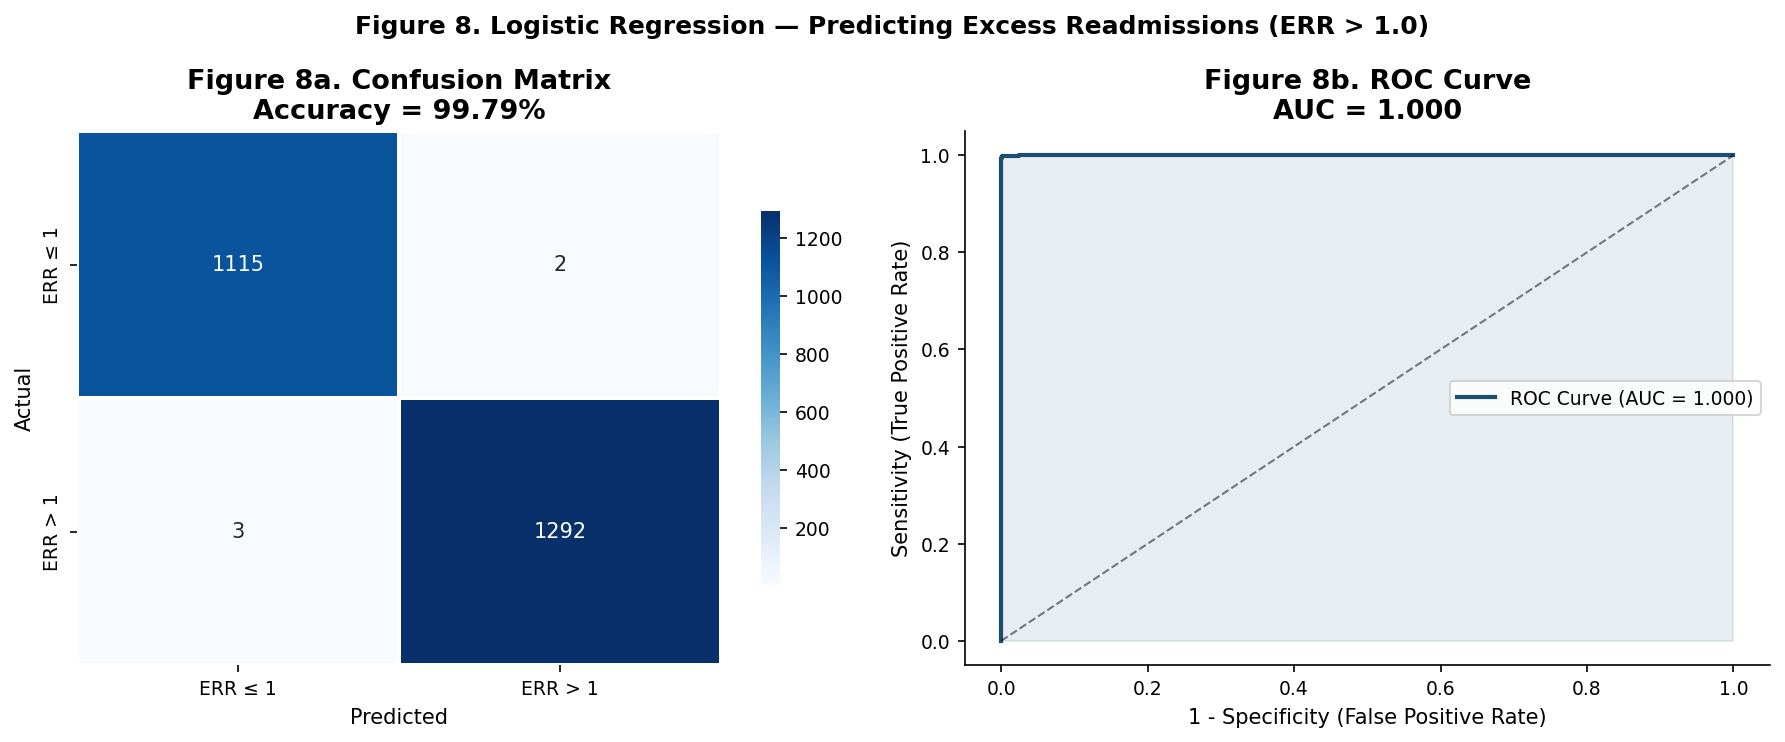

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['ERR ≤ 1', 'ERR > 1'],
            yticklabels=['ERR ≤ 1', 'ERR > 1'],
            linewidths=1, linecolor='white', cbar_kws={'shrink': 0.7})
axes[0].set_xlabel('Predicted', fontsize=10)
axes[0].set_ylabel('Actual', fontsize=10)
axes[0].set_title(f'Figure 8a. Confusion Matrix\nAccuracy = {acc*100:.2f}%', fontweight='bold')

# ROC Curve
axes[1].plot(fpr, tpr, color=BLUE_MAIN, lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.1, color=BLUE_MAIN)
axes[1].set_xlabel('1 - Specificity (False Positive Rate)', fontsize=10)
axes[1].set_ylabel('Sensitivity (True Positive Rate)', fontsize=10)
axes[1].set_title(f'Figure 8b. ROC Curve\nAUC = {roc_auc:.3f}', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Figure 8. Logistic Regression — Predicting Excess Readmissions (ERR > 1.0)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT + 'fig8_logistic_regression.png', bbox_inches='tight')
print("✓ Figure 8 saved")
plt.show()

# FIGURE 9: Odds Ratio / Coefficient Plot ────────────────────────────────────────────────────────────

✓ Figure 9 saved


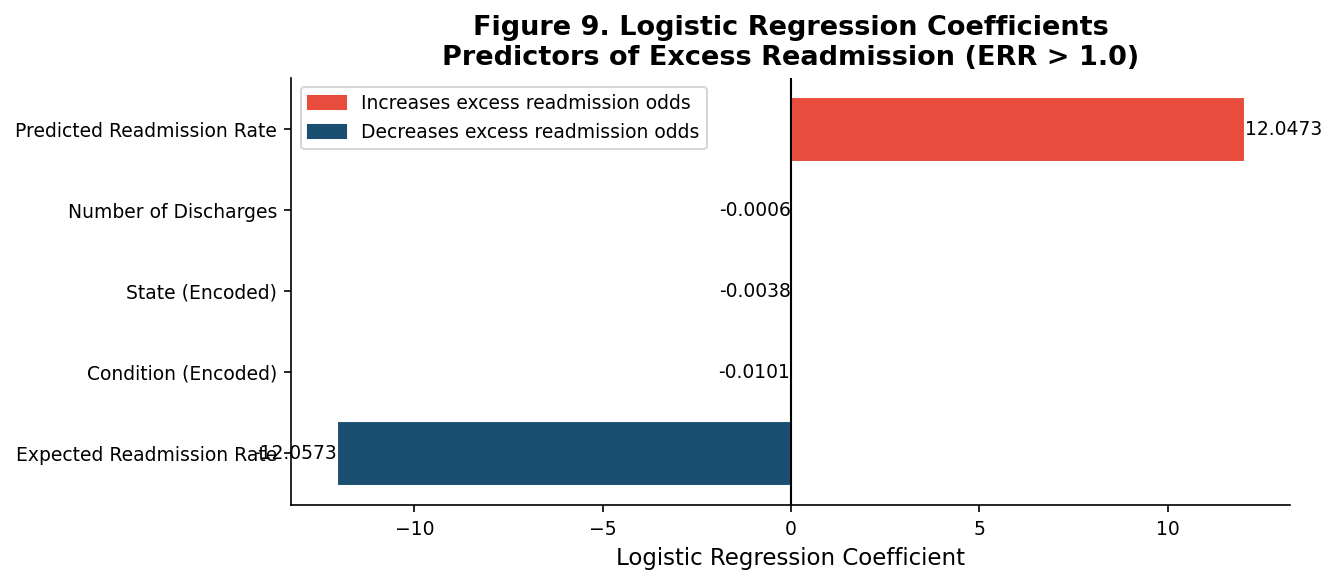

In [20]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')
 
colors_coef = [RED_MAIN if c > 0 else BLUE_MAIN for c in coef_df['Coefficient']]
feature_labels = {
    'Predicted Readmission Rate': 'Predicted Readmission Rate',
    'Expected Readmission Rate':  'Expected Readmission Rate',
    'Number of Discharges':        'Number of Discharges',
    'Condition_enc':               'Condition (Encoded)',
    'State_enc':                   'State (Encoded)',
}
coef_df['Label'] = coef_df['Feature'].map(feature_labels)
 
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(coef_df['Label'], coef_df['Coefficient'], color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
for bar, val in zip(bars, coef_df['Coefficient']):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Figure 9. Logistic Regression Coefficients\n'
             'Predictors of Excess Readmission (ERR > 1.0)')
red_patch  = mpatches.Patch(color=RED_MAIN,  label='Increases excess readmission odds')
blue_patch = mpatches.Patch(color=BLUE_MAIN, label='Decreases excess readmission odds')
ax.legend(handles=[red_patch, blue_patch], fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig9_coefficients.png', bbox_inches='tight')
print("✓ Figure 9 saved")
plt.show()
 

# FIGURE 10: Top 15 States — % Hospitals with Excess Readmissions ───────────────────────────────────────────────────────────────

✓ Figure 10 saved


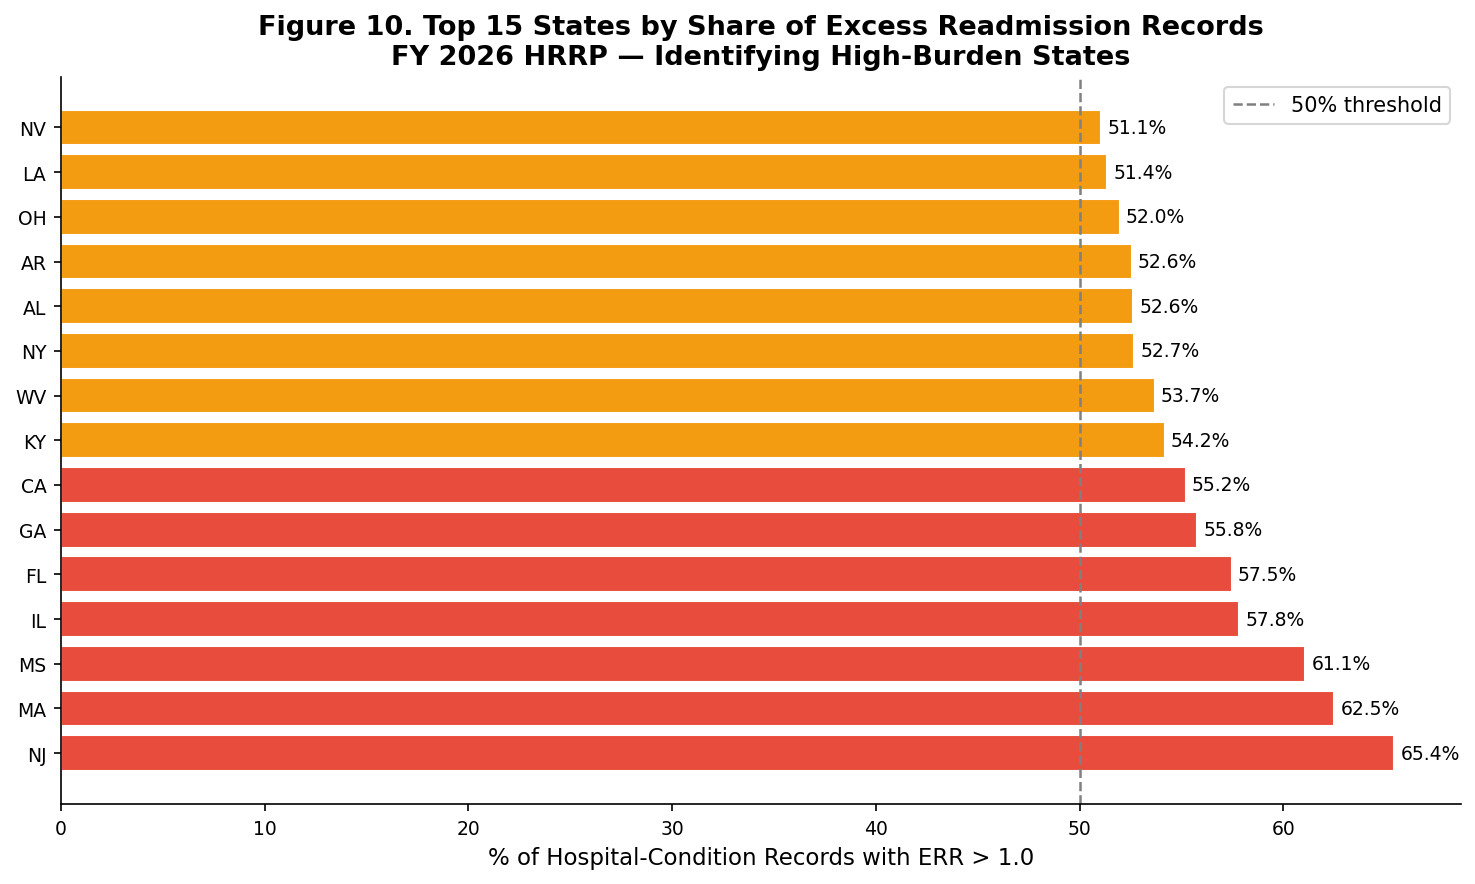

In [21]:
state_excess = df.groupby('State').agg(
    total=('Excess_Flag', 'count'),
    excess=('Excess_Flag', 'sum')
).reset_index()
state_excess['pct_excess'] = state_excess['excess'] / state_excess['total'] * 100
state_excess = state_excess.sort_values('pct_excess', ascending=False).head(15)
 
fig, ax = plt.subplots(figsize=(10, 6))
colors_state = [RED_MAIN if v > 55 else ORANGE if v > 50 else BLUE_MAIN
                for v in state_excess['pct_excess']]
bars = ax.barh(state_excess['State'], state_excess['pct_excess'],
               color=colors_state, edgecolor='white')
ax.axvline(50, color='grey', linestyle='--', linewidth=1.2, label='50% threshold')
for bar, val in zip(bars, state_excess['pct_excess']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% of Hospital-Condition Records with ERR > 1.0')
ax.set_title('Figure 10. Top 15 States by Share of Excess Readmission Records\n'
             'FY 2026 HRRP — Identifying High-Burden States')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT + 'fig10_state_excess_burden.png', bbox_inches='tight')
print("✓ Figure 10 saved")
plt.show()

# SUMMARY PRINT ────────────────────────────────────────────────────────────

Could not save summary CSV: name 'OUTPUT' is not defined
Could not render/save summary image: name 'OUTPUT' is not defined


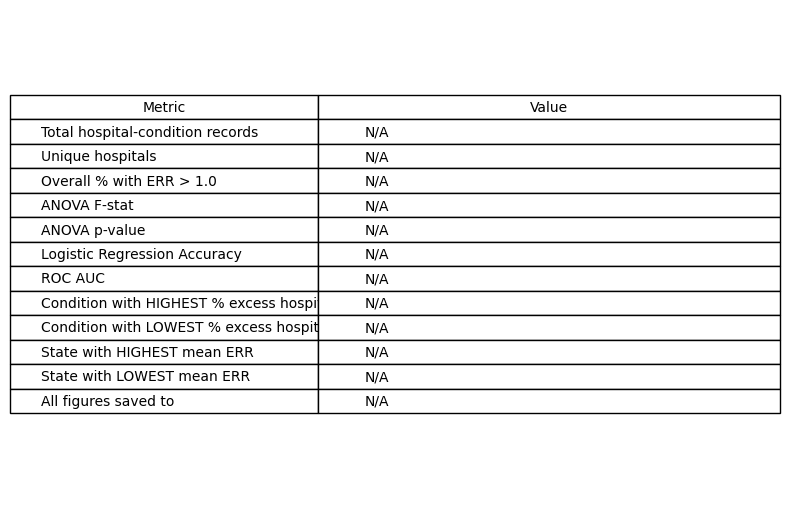

In [ ]:
# Local imports to guard against running this cell in a fresh kernel
import os
import pandas as pd
import matplotlib.pyplot as plt

# Determine and prepare output path (use existing OUTPUT if defined)
output_path = globals().get('OUTPUT', 'outputs/')
# Normalize and ensure trailing separator
output_path = os.path.normpath(output_path) + os.sep
os.makedirs(output_path, exist_ok=True)

# Create a concise summary table and save as CSV + PNG (guarded so missing vars won't crash)
summary_items = {}
# core dataset metrics (guarded)
try:
    summary_items['Total hospital-condition records'] = f"{len(df):,}"
except Exception:
    summary_items['Total hospital-condition records'] = 'N/A'
try:
    summary_items['Unique hospitals'] = f"{df['Facility ID'].nunique():,}"
except Exception:
    summary_items['Unique hospitals'] = 'N/A'
try:
    summary_items['Overall % with ERR > 1.0'] = f"{df['Excess_Flag'].mean()*100:.1f}%"
except Exception:
    summary_items['Overall % with ERR > 1.0'] = 'N/A'
# ANOVA results (if available)
summary_items['ANOVA F-stat'] = f"{f_stat:.2f}" if 'f_stat' in globals() else 'N/A'
summary_items['ANOVA p-value'] = f"{p_val:.4e}" if 'p_val' in globals() else 'N/A'
# Logistic / ROC metrics (if available)
summary_items['Logistic Regression Accuracy'] = f"{acc*100:.2f}%" if 'acc' in globals() else 'N/A'
summary_items['ROC AUC'] = f"{roc_auc:.3f}" if 'roc_auc' in globals() else 'N/A'
# Condition / State highlights (guarded)
try:
    summary_items['Condition with HIGHEST % excess hospitals'] = f"{excess_rate.idxmax()} ({excess_rate.max():.1f}%)"
except Exception:
    summary_items['Condition with HIGHEST % excess hospitals'] = 'N/A'
try:
    summary_items['Condition with LOWEST % excess hospitals'] = f"{excess_rate.idxmin()} ({excess_rate.min():.1f}%)"
except Exception:
    summary_items['Condition with LOWEST % excess hospitals'] = 'N/A'
try:
    summary_items['State with HIGHEST mean ERR'] = f"{state_err.idxmax()} ({state_err.max():.4f})"
except Exception:
    summary_items['State with HIGHEST mean ERR'] = 'N/A'
try:
    summary_items['State with LOWEST mean ERR'] = f"{state_err.idxmin()} ({state_err.min():.4f})"
except Exception:
    summary_items['State with LOWEST mean ERR'] = 'N/A'
summary_items['All figures saved to'] = output_path
# Build DataFrame
summary_df = pd.DataFrame(list(summary_items.items()), columns=['Metric', 'Value'])
# Save CSV
try:
    csv_path = os.path.join(output_path, 'summary_table.csv')
    summary_df.to_csv(csv_path, index=False)
    print('\u2713 Summary CSV saved to', csv_path)
except Exception as e:
    print('Could not save summary CSV:', e)
# Render as an image using matplotlib table
try:
    fig, ax = plt.subplots(figsize=(8, max(2, 0.35 * len(summary_df) + 1)))
    ax.axis('off')
    tbl = ax.table(cellText=summary_df.values, colLabels=summary_df.columns, cellLoc='left', loc='center', colWidths=[0.4, 0.6])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.2)
    plt.tight_layout()
    img_path = os.path.join(output_path, 'summary_table.png')
    plt.savefig(img_path, bbox_inches='tight')
    print('\u2713 Summary image saved to', img_path)
    plt.show()
except Exception as e:
    print('Could not render/save summary image:', e)
